## PTID-AI-MAR-26-1134_PRAICP-1001-GenderDetc

### Import Libraries

In [68]:
import pathlib, numpy as np, tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing import image_dataset_from_directory

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

### Initial Configuration

In [69]:
import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

### Initial Declarations

In [70]:
ROOT = "/kaggle/input/datasets/bharaniamarnath/gender-detection-dataset"
IMG_SIZE = (128,128)
BATCH_SIZE = 32
SEED = 42
NUM_EPOCHS_HEAD = 10
NUM_EPOCHS_FINETUNE = 8

### Dataset

In [71]:
train_ds = image_dataset_from_directory(ROOT, validation_split=0.2, subset="training",
                                        seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True)
val_ds = image_dataset_from_directory(ROOT, validation_split=0.2, subset="validation",
                                      seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

Found 2307 files belonging to 2 classes.
Using 1846 files for training.
Found 2307 files belonging to 2 classes.
Using 461 files for validation.


### Data Analysis

In [72]:
class_names = train_ds.class_names
print("class_names:", class_names)

class_names: ['man', 'woman']


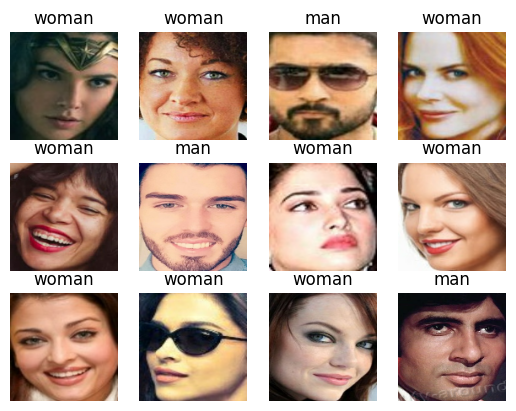

In [73]:
for i,(img,lab) in enumerate(train_ds.unbatch().take(12)):
    ax=plt.subplot(3,4,i+1)
    im = img.numpy()
    if im.max() <= 1.0:
        im_disp = (im * 255).astype("uint8")
    else:
        im_disp = im.astype("uint8")
    plt.imshow(im_disp)
    ax.set_title(class_names[int(lab.numpy())])
    plt.axis('off')
plt.show()

In [74]:
for imgs, labels in val_ds.unbatch().batch(64).take(5):
    preds = np.argmax(model.predict(imgs), axis=1)
    print("true counts:", np.bincount(labels.numpy(), minlength=2), "pred counts:", np.bincount(preds, minlength=2))
    # show misclassified examples
    mis = np.where(preds != labels.numpy())[0]
    print("misclassified indices:", mis[:10])
    break

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
true counts: [ 0 64] pred counts: [ 1 63]
misclassified indices: [58]


### Data Preprocessing

In [75]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [76]:
# Optional: compute class weights (counts are nearly balanced; still shown)
labels = np.concatenate([y.numpy() for _, y in train_ds.unbatch().batch(1024)])
cw = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(cw))
print("class_weight:", class_weight_dict)

class_weight: {0: np.float64(0.9850586979722519), 1: np.float64(1.0154015401540153)}


In [77]:
# Augmentation + preprocessing
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomContrast(0.06),
])

In [78]:
preprocess_input = layers.Rescaling(1./255)

### Build Model

In [79]:
# Build model with MobileNetV2 backbone
base = tf.keras.applications.MobileNetV2(input_shape=(*IMG_SIZE,3), include_top=False, weights='imagenet')
base.trainable = False

In [80]:
model = models.Sequential([
    layers.Input((*IMG_SIZE,3)),
    data_augmentation,
    preprocess_input,
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

### Compile Model

In [81]:
model.compile(optimizer=optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Model Summary

In [82]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Model Callbacks

In [83]:
checkpoint = callbacks.ModelCheckpoint("best_mobilenet.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1)
early = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

### Train Model

In [84]:
history_head = model.fit(train_ds, validation_data=val_ds, epochs=NUM_EPOCHS_HEAD,
                         callbacks=[checkpoint, reduce_lr, early],
                         class_weight=class_weight_dict)

Epoch 1/10
56/58 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7188 - loss: 0.6675
Epoch 1: val_accuracy improved from -inf to 0.92408, saving model to best_mobilenet.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.7217 - loss: 0.6611 - val_accuracy: 0.9241 - val_loss: 0.1791 - learning_rate: 0.0010
Epoch 2/10
56/58 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8485 - loss: 0.3582
Epoch 2: val_accuracy did not improve from 0.92408
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8486 - loss: 0.3587 - val_accuracy: 0.8698 - val_loss: 0.3010 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8445 - loss: 0.3806
Epoch 3: val_accuracy did not improve from 0.92408
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8445 - loss: 0.3802 - val_accuracy: 0.9111 - val_loss: 0.2067 - learning_rate: 0.0010
Epoch 4/10
56/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8547 - loss: 0.3217
Epoch 4: val_accuracy improved from 0.92408 to 0.93492, saving model to best_mobilenet.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8554 - loss: 0.3206 - val_accuracy: 0.9349 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8619 - loss: 0.3565
Epoch 5: val_accuracy improved from 0.93492 to 0.94577, saving model to best_mobilenet.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8618 - loss: 0.3562 - val_accuracy: 0.9458 - val_loss: 0.1447 - learning_rate: 0.0010
Epoch 6/10
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8814 - loss: 0.2879
Epoch 6: val_accuracy improved from 0.94577 to 0.94794, saving model to best_mobilenet.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8814 - loss: 0.2882 - val_accuracy: 0.9479 - val_loss: 0.1310 - learning_rate: 0.0010
Epoch 7/10
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8899 - loss: 0.2787
Epoch 7: val_accuracy improved from 0.94794 to 0.96095, saving model to best_mobilenet.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8896 - loss: 0.2795 - val_accuracy: 0.9610 - val_loss: 0.1060 - learning_rate: 0.0010
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8854 - loss: 0.2899
Epoch 8: val_accuracy did not improve from 0.96095
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8853 - loss: 0.2900 - val_accuracy: 0.9393 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 9/10
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8852 - loss: 0.2784
Epoch 9: val_accuracy did not improve from 0.96095
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8850 - loss: 0.2785 - val_accuracy: 0.9566 - val_loss: 0.1174 - learning_rate: 0.0010
Epoch 10/10
56/58 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8834 - loss: 0.2665
Epoch 10: val_accuracy did not improve from 0.96095

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8833 - loss: 0.2673 - val_accuracy: 0.

### Unfreeze Layers

In [85]:
# Unfreeze top of base and fine-tune
base.trainable = True

In [86]:
# Unfreeze only last few layers
for layer in base.layers[:-40]:
    layer.trainable = False

### Compile Model

In [87]:
model.compile(optimizer=optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Train Model

In [88]:
history_finetune = model.fit(train_ds, validation_data=val_ds, epochs=NUM_EPOCHS_FINETUNE,
                             callbacks=[checkpoint, reduce_lr, early],
                             class_weight=class_weight_dict)

Epoch 1/8
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7227 - loss: 0.8034
Epoch 1: val_accuracy improved from 0.96095 to 0.96963, saving model to best_mobilenet.h5


58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.7232 - loss: 0.8022 - val_accuracy: 0.9696 - val_loss: 0.0830 - learning_rate: 1.0000e-05
Epoch 2/8
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7963 - loss: 0.5271
Epoch 2: val_accuracy did not improve from 0.96963
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7965 - loss: 0.5272 - val_accuracy: 0.9696 - val_loss: 0.0894 - learning_rate: 1.0000e-05
Epoch 3/8
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8569 - loss: 0.3787
Epoch 3: val_accuracy did not improve from 0.96963
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8567 - loss: 0.3790 - val_accuracy: 0.9653 - val_loss: 0.1005 - learning_rate: 1.0000e-05
Epoch 4/8
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8671 - loss: 0.3069
Epoch 4: val_accuracy did not improve from 0.96963

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8673 - loss: 0.3075 - val_accur

### Model Evaluation

In [89]:
y_true=[]; y_pred=[]
for x,y in val_ds.unbatch().batch(64):
    preds = model.predict(x)
    y_true.extend(y.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


#### Confusion Matrix

In [90]:
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

Confusion matrix:
[[  0   0]
 [ 14 447]]


#### Classification Report

In [91]:
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification report:
              precision    recall  f1-score   support

         man       0.00      0.00      0.00         0
       woman       1.00      0.97      0.98       461

    accuracy                           0.97       461
   macro avg       0.50      0.48      0.49       461
weighted avg       1.00      0.97      0.98       461



### Plot: Loss, Accuracy vs Epochs

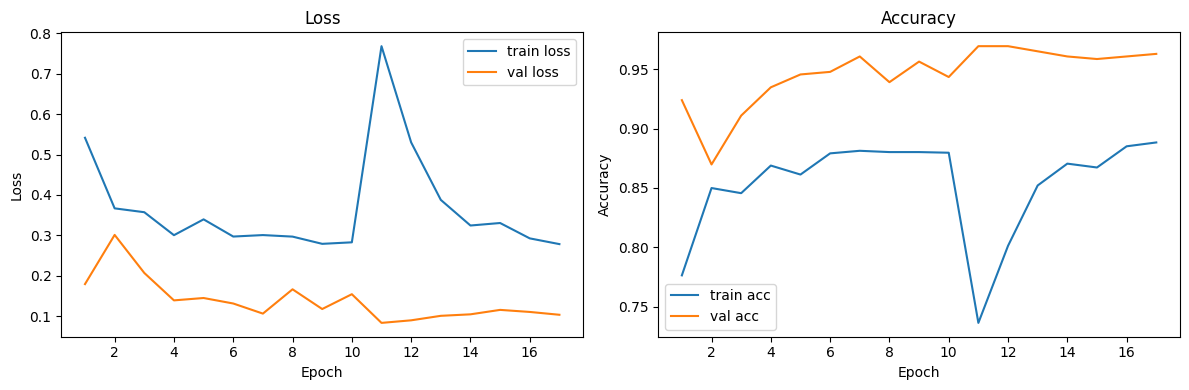

In [92]:
def combine_histories(h1, h2):
    out = {}
    for k in h1.history.keys():
        out[k] = h1.history[k] + h2.history.get(k, [])
    return out

hist = combine_histories(history_head, history_finetune) if ('history_finetune' in globals()) else history_head.history

epochs = range(1, len(hist['loss'])+1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, hist['loss'], label='train loss')
plt.plot(epochs, hist.get('val_loss', []), label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, hist.get('accuracy', hist.get('acc', [])), label='train acc')
plt.plot(epochs, hist.get('val_accuracy', hist.get('val_acc', [])), label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()


### Heatmap: Confusion Matrix

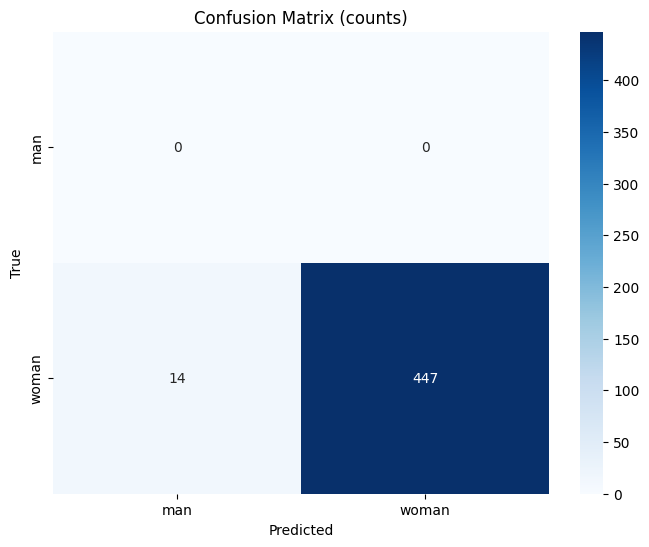

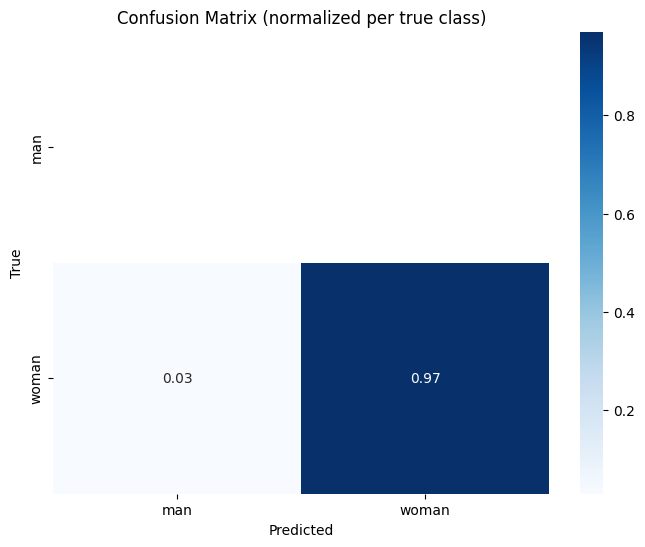

In [93]:

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # per-class recall normalization

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (counts)')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (normalized per true class)')
plt.show()

### Save Model

In [94]:
# Save final model
model.save("PRAICP-1001-GenderDetc_Mobilenet.keras")

### Model Prediction

In [95]:
# Inference helper
import numpy as np
from tensorflow.keras.preprocessing import image
def predict_image(img_path, model_path="/kaggle/working/PRAICP-1001-GenderDetc_Mobilenet.keras"):
    model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    preds = model.predict(x)[0]
    idx = int(np.argmax(preds))
    return {"class": class_names[idx], "probabilities": preds.tolist()}

In [96]:
# Sample Test (Woman):
result_1 = predict_image("/kaggle/input/datasets/bharaniamarnath/gender-detection-dataset/woman/face_102.jpg", "/kaggle/working/PRAICP-1001-GenderDetc_Mobilenet.keras")
print(result_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
{'class': 'woman', 'probabilities': [0.12273072451353073, 0.8772693276405334]}


In [97]:
# Sample Test (Man):
result_2 = predict_image("/kaggle/input/datasets/bharaniamarnath/gender-detection-dataset/man/face_1019.jpg", "/kaggle/working/PRAICP-1001-GenderDetc_Mobilenet.keras")
print(result_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
{'class': 'man', 'probabilities': [0.9795593023300171, 0.020440630614757538]}
